# Evaluate model on data splits

In this notebook, we look at the performance of TCRStructMap on different data splitting strategies. We also look at the peptide channels and MHC pseudo sequence channels separately to note that the MHC channel can provide a shortcut for learning under some splitting strategies.

In [1]:
import collections
import itertools

import IPython.display as ipy_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.metrics import roc_auc_score

In [ ]:
ablations = ('', 'cdrs_peptide', 'cdrs_mhc_pseudo')
data_splits = ('random', 'peptide', 'pMHC')

In [3]:
predictions = []
for data_split in data_splits:
    for ablation in ablations:
        prediction = pd.read_csv(
            f"data/processed/TCRStructMap_{ablation + '_' if ablation else ablation}predictions_on_sequences_"
            f'{data_split}_split.csv'
        )

        prediction['data_split'] = data_split
        prediction['ablation'] = ablation

        sequences = pd.read_csv(f'data/interim/sequences_{data_split}_split.csv', index_col='index')
        prediction = prediction.merge(sequences, how='left', left_on='index', right_index=True)

        prediction = prediction[prediction['fold'] == prediction['sub_model_number']].reset_index(drop=True)

        predictions.append(prediction)

predictions = pd.concat(predictions).reset_index(drop=True)

In [4]:
NUM_SAMPLES = 25
SAMPLE_SIZE = 500

indices = predictions['index'].unique()
rng = np.random.default_rng(123)

samples_metric_scores = []
for sample_num in range(1, NUM_SAMPLES + 1):
    sample_indices = rng.choice(indices, SAMPLE_SIZE)

    sample = predictions[predictions['index'].isin(sample_indices)]

    for (data_split, ablation), group in sample.groupby(['data_split', 'ablation'], dropna=False):
        score = roc_auc_score(group['label'], group['prediction'])
        samples_metric_scores.append(
            {
                'sample_num': sample_num,
                'data_split': data_split,
                'ablation': ablation,
                'roc_auc_score': score,
            }
        )

samples_metric_scores = pd.DataFrame(samples_metric_scores)

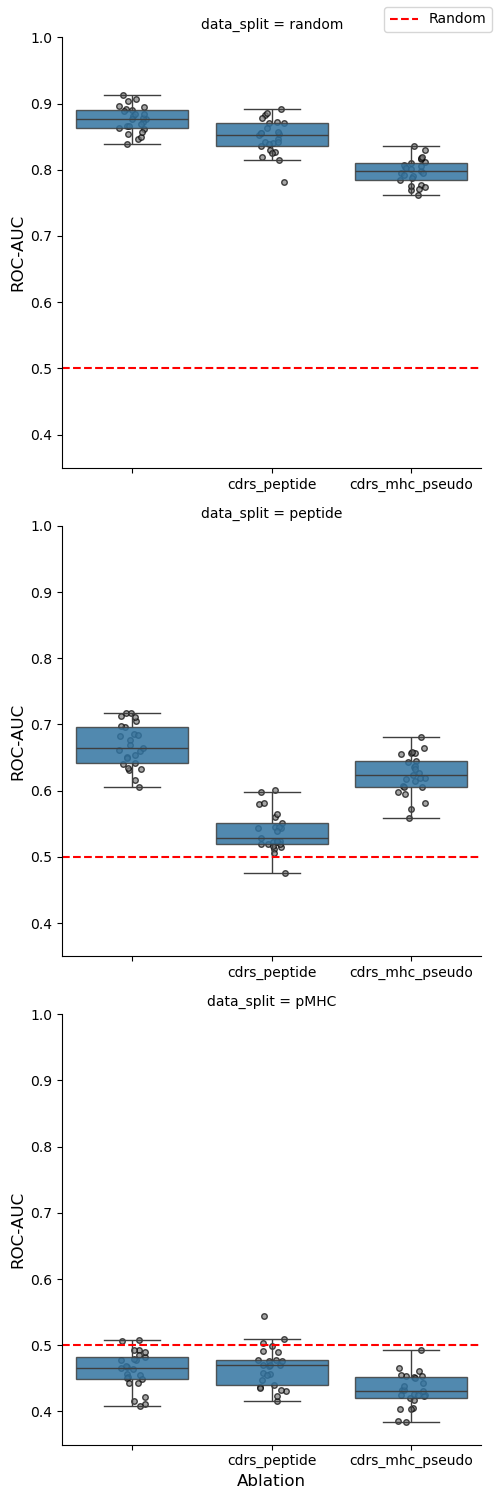

In [5]:
grid = sns.FacetGrid(samples_metric_scores, row='data_split', row_order=data_splits, sharex=False, height=5)

grid.map_dataframe(
    sns.boxplot, x='ablation', y='roc_auc_score', order=ablations, showfliers=False, boxprops={'alpha': 0.85}, zorder=1
)
grid.map_dataframe(
    sns.stripplot,
    x='ablation',
    y='roc_auc_score',
    order=ablations,
    color='grey',
    marker='o',
    size=4,
    edgecolor='black',
    linewidth=1,
    alpha=0.70,
    zorder=0,
)

grid.refline(y=0.5, color='red')
refline_handle = Line2D([0], [0], color='red', linestyle='--', label='Random')
grid.figure.legend(handles=[refline_handle], loc='upper right')

grid.set(ylim=(0.35, 1.0))
grid.set_axis_labels('Ablation', 'ROC-AUC', fontsize=12)

plt.savefig('report/figures/data_split_evaluation.svg')
plt.show()

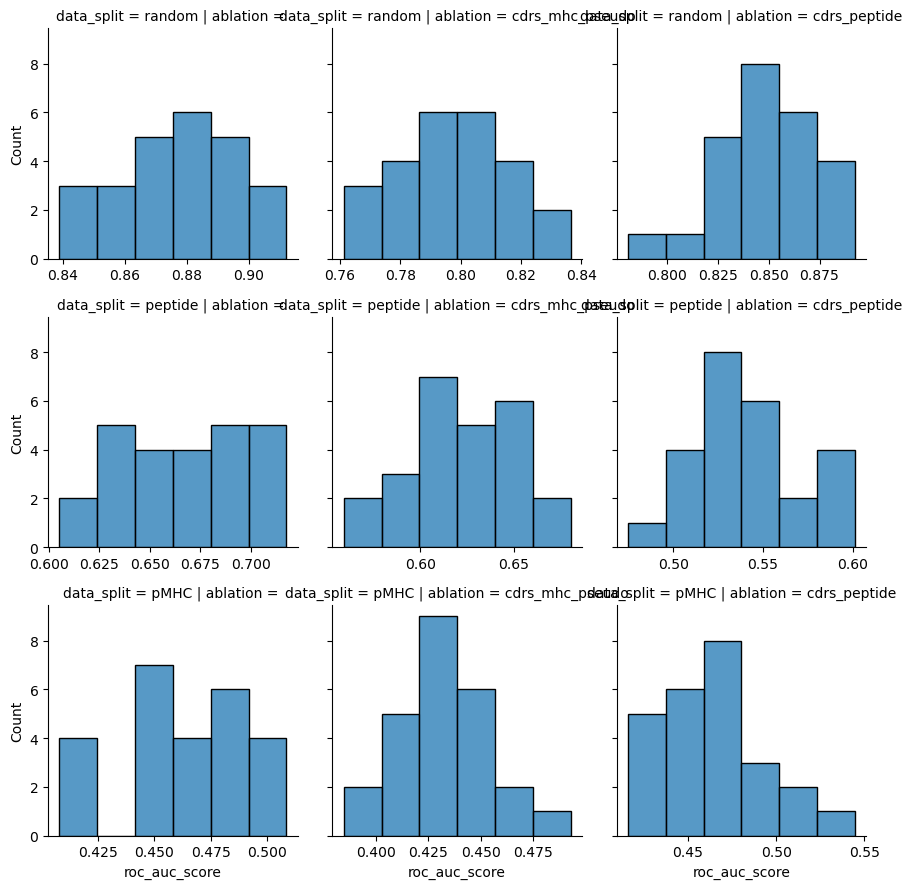

In [6]:
grid = sns.FacetGrid(samples_metric_scores, row='data_split', row_order=data_splits, col='ablation', sharex=False)
grid.map_dataframe(sns.histplot, x='roc_auc_score')
plt.show()

In [7]:
ipy_display.display(
    pg.rm_anova(samples_metric_scores, dv='roc_auc_score', within=['data_split', 'ablation'], subject='sample_num')
)

groups = list(
    samples_metric_scores.set_index('sample_num').groupby(['data_split', 'ablation'], dropna=False)['roc_auc_score']
)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

ipy_display.display(pd.DataFrame(results))

/ceph/project/koohylab/bmcmaste/miniconda3/envs/tcr-antigen-prediction/lib/python3.11/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,data_split,5.694643,2,48,2.847321,1855.028726,3.553593e-46,5.740910e-43,0.972869,0.926785
1,ablation,0.129963,2,48,0.064981,178.351481,6.005048e-23,3.380594e-21,0.450052,0.915193
2,data_split * ablation,0.185805,4,96,0.046451,227.685247,4.534962e-48,8.507024e-22,0.539167,0.425243


,group1,group2,stat,p_val,signficant
0,"(pMHC, )","(pMHC, cdrs_mhc_pseudo)",3.0,2.980232e-07,True
1,"(pMHC, )","(pMHC, cdrs_peptide)",127.0,3.525196e-01,False
2,"(pMHC, )","(peptide, )",0.0,5.960464e-08,True
3,"(pMHC, )","(peptide, cdrs_mhc_pseudo)",0.0,5.960464e-08,True
4,"(pMHC, )","(peptide, cdrs_peptide)",0.0,5.960464e-08,True
5,"(pMHC, )","(random, )",0.0,5.960464e-08,True
6,"(pMHC, )","(random, cdrs_mhc_pseudo)",0.0,5.960464e-08,True
7,"(pMHC, )","(random, cdrs_peptide)",0.0,5.960464e-08,True
8,"(pMHC, cdrs_mhc_pseudo)","(pMHC, cdrs_peptide)",0.0,5.960464e-08,True
9,"(pMHC, cdrs_mhc_pseudo)","(peptide, )",0.0,5.960464e-08,True
